In [1]:
cd /

/


In [2]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 901.7/901.7 kB 14.5 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
cp -r /kaggle/input/ultralytics/ultralytics ultralytics

In [4]:
# Disable warnings in the notebook to maintain clean output cells
import warnings
warnings.filterwarnings('ignore')

# Import necessary libraries
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import cv2
import yaml
from PIL import Image
from collections import deque
from ultralytics import YOLO
from IPython.display import Video

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
cd ultralytics

/ultralytics


In [6]:
sns.set_theme(rc={'axes.facecolor': '#ffe4de'}, style='darkgrid')

In [7]:
if __name__ == '__main__':
    model = YOLO("/kaggle/input/ultralytics/ultralytics/cfg/models/v8/SA-SS-seg.yaml") 

WARNING ⚠️ no model scale passed. Assuming scale='n'.


In [8]:
# set the dataset
dataset_path = '/kaggle/input/1822-a/1822a'
yaml_file_path = os.path.join(dataset_path, 'data.yaml')
print(yaml_file_path)
with open(yaml_file_path, 'r') as file:
    yaml_content = yaml.load(file, Loader=yaml.FullLoader)
    print(yaml.dump(yaml_content, default_flow_style=False))

/kaggle/input/1822-a/1822a/data.yaml
names:
- curb
nc: 1
roboflow:
  license: CC BY 4.0
  project: xiaoshuai
  url: https://universe.roboflow.com/yolov5-joo2t/xiaoshuai/dataset/7
  version: 7
  workspace: yolov5-joo2t
test: ../test/images
train: ../train/images
val: ../valid/images



In [9]:
# Set paths for training and validation image sets
train_images_path = os.path.join(dataset_path, 'train', 'images')
valid_images_path = os.path.join(dataset_path, 'valid', 'images')
# test_images_path = os.path.join(dataset_path, 'test', 'images')
# Initialize counters for the number of images
num_train_images = 0
num_valid_images = 0
# num_test_images = 0

# Initialize sets to hold the unique sizes of images
train_image_sizes = set()
valid_image_sizes = set()
# test_image_sizes = set()

In [10]:
# Check train images sizes and count
for filename in os.listdir(train_images_path):
    if filename.endswith('.jpg'):
        num_train_images += 1
        image_path = os.path.join(train_images_path, filename)
        with Image.open(image_path) as img:
            train_image_sizes.add(img.size)

# Check validation images sizes and count
for filename in os.listdir(valid_images_path):
    if filename.endswith('.jpg'):
        num_valid_images += 1
        image_path = os.path.join(valid_images_path, filename)
        with Image.open(image_path) as img:
            valid_image_sizes.add(img.size)

In [11]:
# Print the results
print(f"Number of training images: {num_train_images}")
print(f"Number of validation images: {num_valid_images}")

Number of training images: 1260
Number of validation images: 562


In [12]:
if len(train_image_sizes) == 1:
    print(f"All training images have the same size: {train_image_sizes.pop()}")
else:
    print("Training images have varying sizes.")

# Check if all images in validation set have the same size
if len(valid_image_sizes) == 1:
    print(f"All validation images have the same size: {valid_image_sizes.pop()}")
else:
    print("Validation images have varying sizes.")

All training images have the same size: (640, 640)
All validation images have the same size: (640, 640)


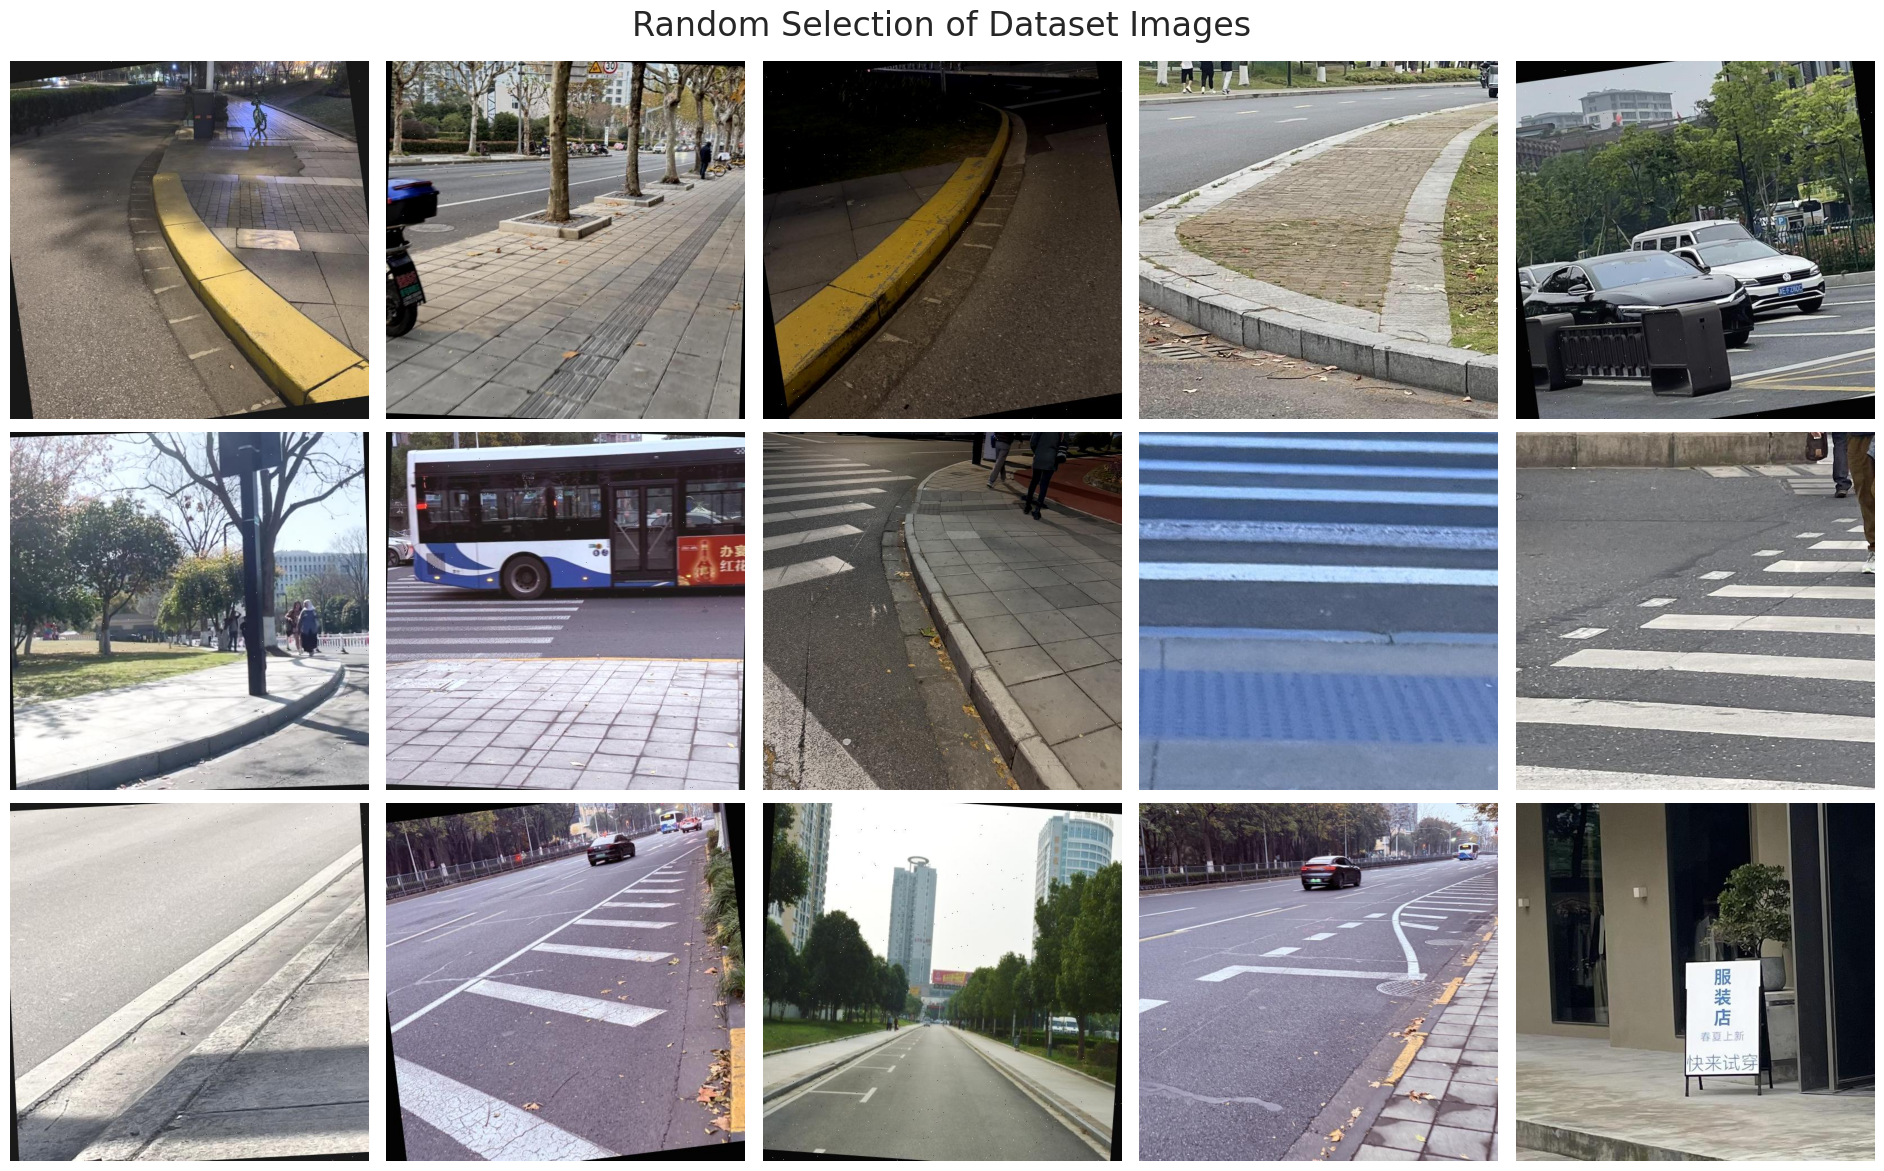

In [13]:
# Set the seed for the random number generator
random.seed(42)

# Create a list of image files
image_files = [f for f in os.listdir(train_images_path) if f.endswith('.jpg')]

# Randomly select 15 images
random_images = random.sample(image_files, 15)

# Create a new figure
plt.figure(figsize=(19, 12))

# Loop through each image and display it in a 3x5 grid
for i, image_file in enumerate(random_images):
    image_path = os.path.join(train_images_path, image_file)
    image = Image.open(image_path)
    plt.subplot(3, 5, i + 1)
    plt.imshow(image)
    plt.axis('off')

# Add a suptitle
plt.suptitle('Random Selection of Dataset Images', fontsize=24)

# Show the plot
plt.tight_layout()
plt.show()

# Deleting unnecessary variable to free up memory
del image_files

In [14]:
# Train the model on our custom dataset
results = model.train(
    data=yaml_file_path,     # Path to the dataset configuration file
    epochs=400,              # Number of epochs to train for
    imgsz=640,               # Size of input images as integer
    patience=50,             # Epochs to wait for no observable improvement for early stopping of training
    batch=4,                # Number of images per batch
    optimizer='SGD',        # Optimizer to use, choices=[SGD, Adam, Adamax, AdamW, NAdam, RAdam, RMSProp, auto]
    lr0=0.01,                # Initial learning rate
    momentum=0.937,          # Momentum for SGD optimizer
    dropout=0.25,            # Use dropout regularization
    device='0',                # Device to run on, i.e. cuda device=0
    seed=42,                  # Random seed for reproducibility
    pretrained='false'
)

New https://pypi.org/project/ultralytics/8.3.52 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.49 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=segment, mode=train, model=/kaggle/input/ultralytics/cfg/models/v8/SA-SS-seg.yaml, data=/kaggle/input/1822-a/1822a/data.yaml, epochs=500, time=None, patience=30, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train4, exist_ok=False, pretrained=false, optimizer=SGD, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.25, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_

100%|██████████| 755k/755k [00:00<00:00, 17.7MB/s]


WARNING ⚠️ no model scale passed. Assuming scale='n'.

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295

train: Scanning /kaggle/input/1822-a/1822a/train/labels... 1260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1260/1260 [00:01<00:00, 652.43it/s]


train: WARNING ⚠️ Cache directory /kaggle/input/1822-a/1822a/train is not writeable, cache not saved.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /kaggle/input/1822-a/1822a/valid/labels... 562 images, 0 backgrounds, 0 corrupt: 100%|██████████| 562/562 [00:01<00:00, 496.21it/s]

val: WARNING ⚠️ Cache directory /kaggle/input/1822-a/1822a/valid is not writeable, cache not saved.


Plotting labels to runs/segment/train4/labels.jpg... 
optimizer: SGD(lr=0.01, momentum=0.937) with parameter groups 97 weight(decay=0.0), 135 weight(decay=0.0005), 134 bias(decay=0.0)
TensorBoard: WARNING ⚠️ TensorBoard graph visualization failure Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument max in method wrapper_CUDA_clamp_Tensor)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to runs/segment/train4
Starting training for 500 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


  0%|          | 0/79 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.44 GiB. GPU 0 has a total capacity of 14.74 GiB of which 1.81 GiB is free. Process 3009 has 12.93 GiB memory in use. Of the allocated memory 11.46 GiB is allocated by PyTorch, and 1.32 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
!ls -lh runs/segment/train4

In [ ]:
cd root/kaggle/working

In [ ]:
!zip -r train_results.zip runs/segment/train4

In [ ]:
!cp -r runs/segment/train4/BoxR_curve.png /kaggle/working/BoxR_curve.png
!cp -r runs/segment/train4/val_batch1_pred.jpg /kaggle/working/val_batch1_pred.jpg
!cp -r runs/segment/train4/MaskF1_curve.png /kaggle/working/MaskF1_curve.png
!cp -r runs/segment/train4/BoxF1_curve.png /kaggle/working/BoxF1_curve.png
!cp -r runs/segment/train4/labels.jpg /kaggle/working/labels.jpg
!cp -r runs/segment/train4/labels_correlogram.jpg /kaggle/working/labels_correlogram.jpg
!cp -r runs/segment/train4/train_batch2.jpg /kaggle/working/train_batch2.jpg
!cp -r runs/segment/train4/val_batch2_pred.jpg /kaggle/working/val_batch2_pred.jpg
!cp -r runs/segment/train4/MaskP_curve.png /kaggle/working/MaskP_curve.png
!cp -r runs/segment/train4/val_batch2_labels.jpg /kaggle/working/val_batch2_labels.jpg
!cp -r runs/segment/train4/BoxP_curve.png /kaggle/working/BoxP_curve.png
!cp -r runs/segment/train4/BoxPR_curve.png /kaggle/working/BoxPR_curve.png
!cp -r runs/segment/train4/weights/best.pt /kaggle/working/best.pt
!cp -r runs/segment/train4/weights/last.pt /kaggle/working/last.pt
!cp -r runs/segment/train4/confusion_matrix_normalized.png /kaggle/working/confusion_matrix_normalized.png
!cp -r runs/segment/train4/results.csv /kaggle/working/results.csv
!cp -r runs/segment/train4/val_batch1_labels.jpg /kaggle/working/val_batch1_labels.jpg
!cp -r runs/segment/train4/args.yaml /kaggle/working/args.yaml
!cp -r runs/segment/train4/results.png /kaggle/working/results.png
!cp -r runs/segment/train4/val_batch0_pred.jpg /kaggle/working/val_batch0_pred.jpg
!cp -r runs/segment/train4/MaskR_curve.png /kaggle/working/MaskR_curve.png
!cp -r runs/segment/train4/train_batch1.jpg /kaggle/working/train_batch1.jpg
!cp -r runs/segment/train4/val_batch0_labels.jpg /kaggle/working/val_batch0_labels.jpg
!cp -r runs/segment/train4/confusion_matrix.png /kaggle/working/confusion_matrix.png
!cp -r runs/segment/train4/MaskPR_curve.png /kaggle/working/MaskPR_curve.png
!cp -r runs/segment/train4/train_batch0.jpg /kaggle/working/train_batch0.jpg

In [ ]:
torch.save(date,runs/segment/train3)

In [ ]:
cd /

In [ ]:
import torch

model_path = 'runs/segment/train4/weights/best.pt'
model = torch.load(model_path)
print("Model loaded successfully!")

In [ ]:
from IPython.display import FileLink

FileLink('train_results.zip')

In [ ]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding
%ls

In [ ]:
cd runs/segment

In [ ]:
# Define the path to the directory
post_training_files_path = 'train4'

# List the files in the directory
!ls {post_training_files_path}

In [ ]:
# Create the full file path by joining the directory path with the filename
results_file_path = os.path.join(post_training_files_path, 'results.png')

# Read the image using cv2
image = cv2.imread(results_file_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image using matplotlib
plt.figure(figsize=(20, 8))
plt.imshow(image)
plt.title('Training and Validation Loss Trends', fontsize=24)
plt.axis('off')
plt.show()

In [ ]:
# Define a function to plot learning curves for loss values
def plot_learning_curve(df, train_loss_col, val_loss_col, title, ylim_range=[0,2]):
    plt.figure(figsize=(12, 4))
    sns.lineplot(data=df, x='epoch', y=train_loss_col, label='Train Loss', color='blue', linestyle='-', linewidth=2)
    sns.lineplot(data=df, x='epoch', y=val_loss_col, label='Validation Loss', color='#ed2f00', linestyle='--', linewidth=2)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.ylim(ylim_range)
    plt.legend()
    plt.show()

In [ ]:
# Create the full file path for 'results.csv' using the directory path and file name
results_csv_path = os.path.join(post_training_files_path, 'results.csv')

# Load the CSV file from the constructed path into a pandas DataFrame
df = pd.read_csv(results_csv_path)

# Remove any leading whitespace from the column names
df.columns = df.columns.str.strip()

# Plot the learning curves for each loss
plot_learning_curve(df, 'train/box_loss', 'val/box_loss', 'Bounding Box Loss Learning Curve')
plot_learning_curve(df, 'train/cls_loss', 'val/cls_loss', 'Classification Loss Learning Curve')
plot_learning_curve(df, 'train/dfl_loss', 'val/dfl_loss', 'Distribution Focal Loss Learning Curve')
plot_learning_curve(df, 'train/seg_loss', 'val/seg_loss', 'Segmentation Loss Learning Curve', ylim_range=[0,5])

In [ ]:
# 评估模型在不同置信水平下的预测性能，使用精度、召回率和F1分数指标对边界框和掩码预测进行评估
# Define the filenames for 'Box' and 'Mask' metrics along with their titles
box_files_titles = {
    'BoxP_curve.png': 'Bounding Box Precision-Confidence Curve',
    'BoxR_curve.png': 'Bounding Box Recall-Confidence Curve',
    'BoxF1_curve.png': 'Bounding Box F1-Confidence Curve'
}
mask_files_titles = {
    'MaskP_curve.png': 'Mask Precision-Confidence Curve',
    'MaskR_curve.png': 'Mask Recall-Confidence Curve',
    'MaskF1_curve.png': 'Mask F1-Confidence Curve'
}

# Create a 3x2 subplot
fig, axs = plt.subplots(3, 2, figsize=(20, 20))

# Function to read and convert image for plotting
def read_and_convert_image(file_path):
    # Read the image using cv2
    image = cv2.imread(file_path)
    # Convert from BGR to RGB
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Plot 'Box' images in the first column with meaningful titles
for i, (filename, title) in enumerate(box_files_titles.items()):
    img_path = os.path.join(post_training_files_path, filename)
    img = read_and_convert_image(img_path)
    axs[i, 0].imshow(img)
    axs[i, 0].set_title(title, fontsize=20)
    axs[i, 0].axis('off')

# Plot 'Mask' images in the second column with meaningful titles
for i, (filename, title) in enumerate(mask_files_titles.items()):
    img_path = os.path.join(post_training_files_path, filename)
    img = read_and_convert_image(img_path)
    axs[i, 1].imshow(img)
    axs[i, 1].set_title(title, fontsize=20)
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Precision-Recall Curve Analysis
# Define the filenames for 'Box' and 'Mask' metrics along with their titles
pr_files_titles = {
    'BoxPR_curve.png': 'Bounding Box Precision-Recall Curve',
    'MaskPR_curve.png': 'Mask Precision-Recall Curve'
}

# Create a 1x2 subplot
fig, axs = plt.subplots(1, 2, figsize=(20, 10))

# Plot 'Box' and 'Mask' images in the subplot with meaningful titles
for i, (filename, title) in enumerate(pr_files_titles.items()):
    img_path = os.path.join(post_training_files_path, filename)
    img = read_and_convert_image(img_path)
    axs[i].imshow(img)
    axs[i].set_title(title, fontsize=20)
    axs[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Confusion Matrix Analysis
# true positive rate真阳性率77%  false negative rate假阴性率23%
# Construct the path to the confusion matrix images
confusion_matrix_path = os.path.join(post_training_files_path, 'confusion_matrix.png')
confusion_matrix_normalized_path = os.path.join(post_training_files_path, 'confusion_matrix_normalized.png')

# Create a 1x2 subplot
fig, axs = plt.subplots(1, 2, figsize=(20, 10))

# Read and convert both images
cm_img = read_and_convert_image(confusion_matrix_path)
cm_norm_img = read_and_convert_image(confusion_matrix_normalized_path)

# Display the images
axs[0].imshow(cm_img)
axs[0].set_title('Confusion Matrix', fontsize=24)
axs[0].axis('off')

axs[1].imshow(cm_norm_img)
axs[1].set_title('Normalized Confusion Matrix', fontsize=24)
axs[1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 验证性能指标评估
# Construct the path to the best model weights file using os.path.join
best_model_path = os.path.join(post_training_files_path, 'weights/best.pt')

# Load the best model weights into the YOLO model
best_model = YOLO(best_model_path)

# Validate the best model using the validation set with default parameters
metrics = best_model.val(split='val')

In [ ]:
# Convert the dictionary to a pandas DataFrame and use the keys as the index
metrics_df = pd.DataFrame.from_dict(metrics.results_dict, orient='index', columns=['Metric Value'])

# Display the DataFrame
metrics_df.round(3)

In [ ]:
# 在验证集中进行推理
# Define the path to the validation images
valid_images_path = os.path.join(dataset_path, 'valid', 'images')

# List all jpg images in the directory
image_files = [file for file in os.listdir(valid_images_path) if file.endswith('.jpg')]

# Select 9 images at equal intervals
num_images = len(image_files)
selected_images = [image_files[i] for i in range(0, num_images, num_images // 9)]

# Initialize the subplot
fig, axes = plt.subplots(3, 3, figsize=(20, 21))
fig.suptitle('Validation Set Inferences', fontsize=24)

# Perform inference on each selected image and display it
for i, ax in enumerate(axes.flatten()):
    image_path = os.path.join(valid_images_path, selected_images[i])
    results = best_model.predict(source=image_path, imgsz=640)
    annotated_image = results[0].plot()
    annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
    ax.imshow(annotated_image_rgb)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 在全新的视频中推理
# Define the destination path in the working directory
video_path = 'WeChat_video.mp4'

# Initiate vehicle detection on the sample video using the best performing model and save the output
best_model.predict(source=video_path, save=True)